# EDA

## Data Acquisition & Environment Setup

In this section, we initialize the connection to our MySQL database and extract the integrated dataset. Note: We use a refined SQL query that utilizes a bridge through the matches table to prevent teams from being incorrectly assigned to multiple leagues (fixing the Cartesian Product error).

In [42]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 7)

load_dotenv()
engine = create_engine(f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}")

# The corrected SQL query ensuring unique league-team mapping
query = """
SELECT 
    l.name as league,
    p.season_year,
    t.name as team,
    p.points,
    p.is_top_5,
    p.goals_for,
    p.goals_against,
    (p.goals_for - p.goals_against) as goal_diff,
    sh.stadium_capacity,
    e.transfer_spend_euro,
    e.net_transfer_spend_euro
FROM team_season_performance p
JOIN teams t ON p.team_id = t.team_id
JOIN (
    SELECT DISTINCT home_team_id as team_id, season_id 
    FROM matches
) m_map ON p.team_id = m_map.team_id
JOIN seasons s ON m_map.season_id = s.season_id AND p.season_year = s.year
JOIN leagues l ON s.league_id = l.league_id
JOIN team_stadium_history sh ON p.team_id = sh.team_id AND p.season_year = sh.season_year
JOIN team_enrichment_data e ON p.team_id = e.team_id AND p.season_year = e.season_year;
"""

df = pd.read_sql(query, engine)
print(f"Dataset Loaded: {df.shape[0]} unique team-season records.")
df.head()

Dataset Loaded: 290 unique team-season records.


,league,season_year,team,points,is_top_5,goals_for,goals_against,goal_diff,stadium_capacity,transfer_spend_euro,net_transfer_spend_euro
0,Premier League,2022,Southampton,25,0,36,73,-37,32689,154210000.0,-148710000.0
1,Premier League,2022,Leeds,31,0,48,78,-30,40204,163890000.0,-49390000.0
2,Premier League,2022,Leicester,34,0,51,68,-17,34310,49000000.0,32400000.0
3,Premier League,2022,Everton,36,0,34,57,-23,52888,83070000.0,20530000.0
4,Premier League,2022,Nottingham Forest,38,0,38,68,-30,30576,198350000.0,-193350000.0


### EDA Kickoff: Data Loaded

The integrated dataset is in memory. We now have one row per team-season with league context, stadium capacity, and transfer figures. Two quick checks guide the next steps:

- Completeness: The printed shape confirms broad coverage across leagues and seasons.
- Sanity: Head preview shows plausible magnitudes (points ~30–90, capacities in tens of thousands).

Next, we engineer simple financial-efficiency features to normalize “spend” against on-pitch output.

## Feature Engineering
To go beyond basic analysis, we define "efficiency" metrics. We want to know the "Price of a Goal" in different leagues. This helps determine if success is "bought" more expensively in a specific league compared to others.

In [43]:
# Handle potential zeros for division
df['transfer_spend_euro'] = df['transfer_spend_euro'].replace(0, 1)

# Metric 1: Cost per Goal (Transfer Spend / Goals For)
df['cost_per_goal_m_euro'] = (df['transfer_spend_euro'] / df['goals_for']) / 1_000_000

# Metric 2: Financial Efficiency (Points earned per 10M Euro spent)
df['points_per_10m_net'] = df['points'] / ((df['net_transfer_spend_euro'].clip(lower=0) / 10_000_000) + 1)

display(df[['team', 'league', 'cost_per_goal_m_euro', 'points_per_10m_net']].head())

,team,league,cost_per_goal_m_euro,points_per_10m_net
0,Southampton,Premier League,4.283611,25.000000
1,Leeds,Premier League,3.414375,31.000000
2,Leicester,Premier League,0.960784,8.018868
3,Everton,Premier League,2.443235,11.791680
4,Nottingham Forest,Premier League,5.219737,38.000000


### Interpretation
- `cost_per_goal_m_euro` approximates how expensive each scored goal is by team-season.
- `points_per_10m_net` contextualizes points relative to net outlay, dampening the impact of extreme net spend.

These features help compare clubs across very different budget scales. Next, we’ll quantify central tendencies and between-league differences to see if money maps cleanly to performance.

## Non-Graphical EDA
We perform a statistical summary of the data to understand the distribution of wealth and sporting performance across the European "Big Five".

In [44]:
# 3.1 General Summary
print("--- Dataset Statistical Overview ---")
summary_display = df.describe().T.round(3)
display(summary_display.style.format(precision=3, thousands=','))

# 3.2 Comparison of League Cultures
print("\n--- Mean Performance/Finance per League ---")
league_summary = df.groupby('league')[['points', 'transfer_spend_euro', 'goals_for', 'stadium_capacity']].mean().round(3)
display(league_summary.sort_values(by='transfer_spend_euro', ascending=False).style.format(precision=3, thousands=','))

--- Dataset Statistical Overview ---


,count,mean,std,min,25%,50%,75%,max
season_year,290.000,"2,022.993",0.819,"2,022.000","2,022.000","2,023.000","2,024.000","2,024.000"
points,290.000,50.428,17.525,12.000,38.000,48.500,62.750,95.000
is_top_5,290.000,0.259,0.439,0.000,0.000,0.000,1.000,1.000
goals_for,290.000,51.924,16.481,23.000,40.000,49.500,61.000,102.000
goals_against,290.000,51.924,13.369,20.000,43.000,51.000,59.000,104.000
goal_diff,290.000,0.000,25.821,-69.000,-15.000,-3.000,18.000,67.000
stadium_capacity,290.000,"39,055.445","18,814.460","10,660.000","23,576.000","34,172.000","53,289.000","85,454.000"
transfer_spend_euro,290.000,"66,222,620.714","78,290,367.663",1.000,"13,235,000.000","40,775,000.000","91,887,500.000","630,250,000.000"
net_transfer_spend_euro,290.000,"-15,840,768.966","65,211,701.929","-562,390,000.000","-30,130,000.000","-2,300,000.000","15,202,500.000","112,700,000.000"
cost_per_goal_m_euro,290.000,1.197,1.465,0.000,0.322,0.766,1.632,16.586



--- Mean Performance/Finance per League ---


,points,transfer_spend_euro,goals_for,stadium_capacity
league,,,,
Premier League,52.433,"149,956,166.667",57.417,"42,162.067"
Serie A,51.500,"55,714,000.017",48.983,"39,439.067"
Ligue 1,48.929,"50,939,642.911",50.071,"33,385.446"
Bundesliga,46.685,"41,685,370.370",53.981,"42,667.389"
La Liga,52.117,"29,345,333.383",49.250,"37,606.450"


### Interpretation
- Summary stats show wide spend dispersion and substantial variability in stadium sizes across leagues.
- League means hint that higher spending does not linearly translate into more points.

Segue: We now visualize key relationships to inspect patterns and outliers that simple averages can hide.

## Graphical EDA - Financial vs. Sporting Success
We visualize the relationship between money spent and the actual "engine" of success: Goal Difference. We use a JointPlot to see both the correlation and the distribution of these variables.

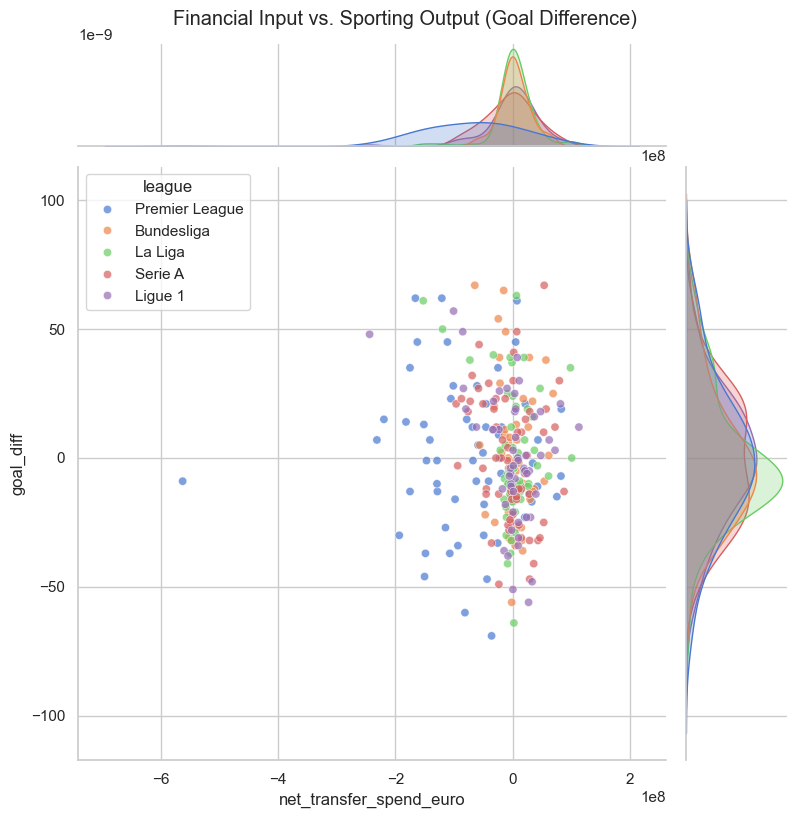

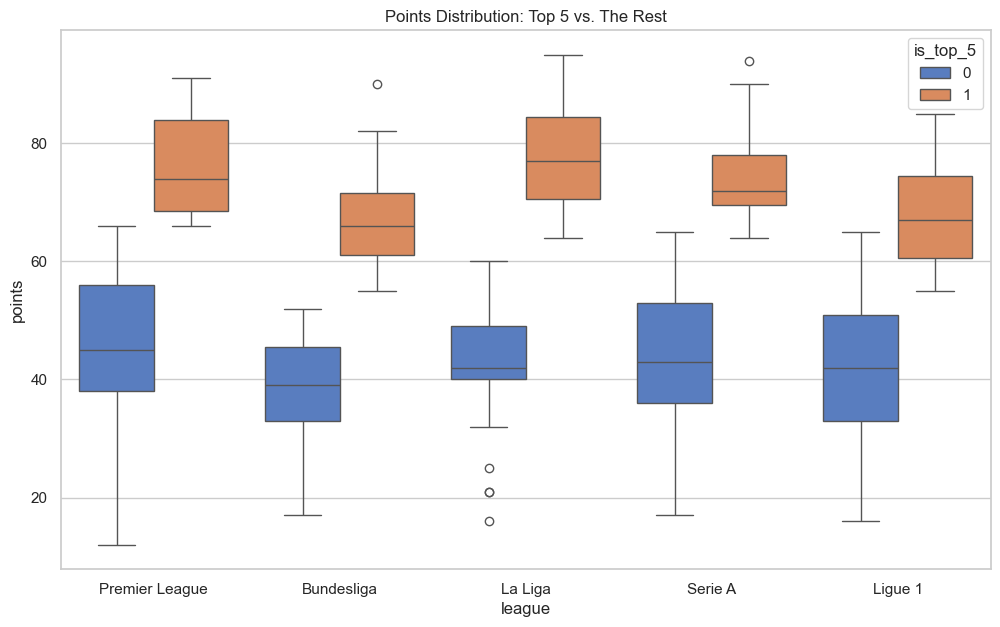

In [45]:
# Scatter plot with distributions (JointPlot)
g = sns.jointplot(data=df, x='net_transfer_spend_euro', y='goal_diff', 
                  hue='league', kind='scatter', alpha=0.7, height=8)
g.fig.suptitle("Financial Input vs. Sporting Output (Goal Difference)", y=1.02)
plt.show()

# Boxplot of Points threshold for 'Elite' status
plt.figure()
sns.boxplot(x='league', y='points', hue='is_top_5', data=df)
plt.title('Points Distribution: Top 5 vs. The Rest')
plt.show()

### Interpretation
- The spend vs. goal-difference scatter suggests only a weak-to-moderate positive association and notable variance within leagues.
- Boxplots confirm overlap: being “Top 5” is not dictated by a single spend threshold.

Segue: We next isolate the role of infrastructure (stadium capacity) relative to points.

## Scatterplot: Stadium Capacity and Points by League

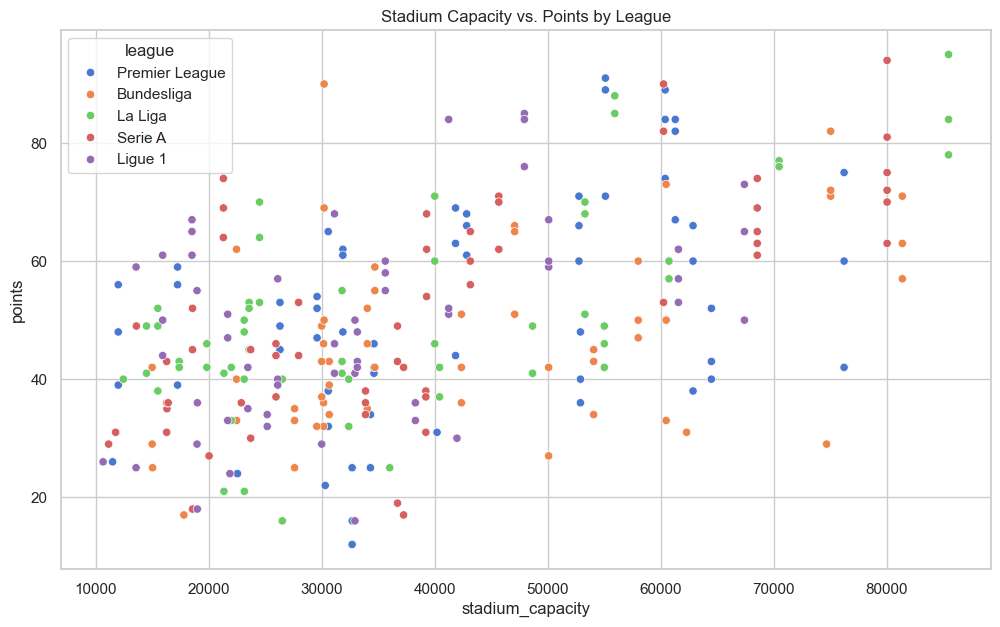

In [46]:
sns.scatterplot(data=df, x='stadium_capacity', y='points', hue='league')
plt.title('Stadium Capacity vs. Points by League')
plt.show()

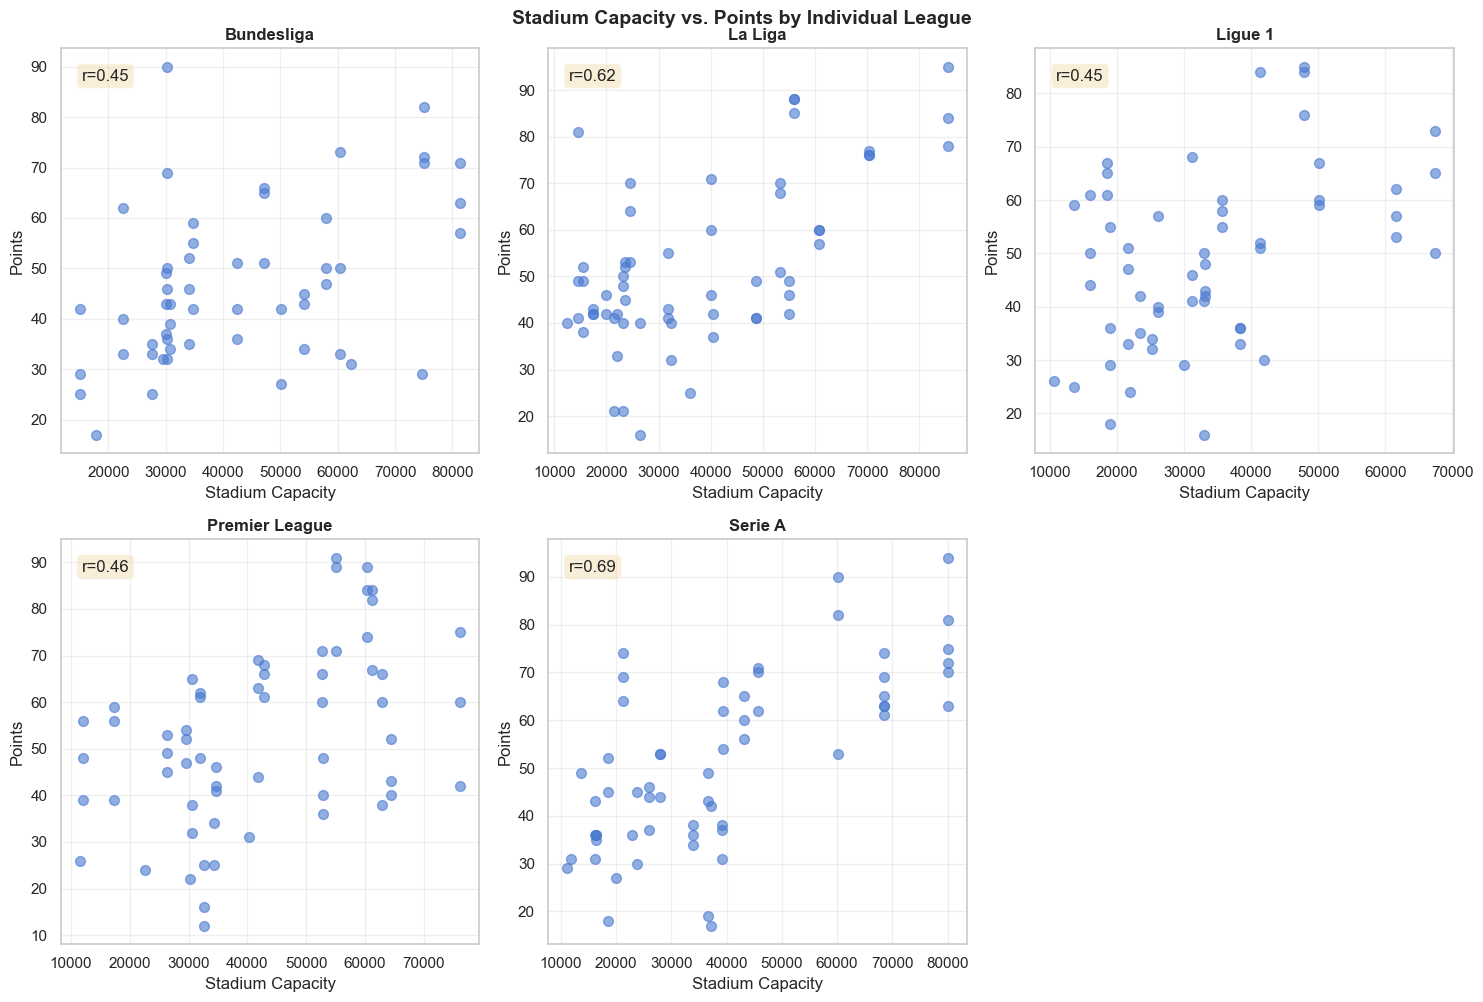

In [47]:

# Individual league scatterplots for detailed comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

leagues = df['league'].unique()
for idx, league in enumerate(sorted(leagues)):
    league_data = df[df['league'] == league]
    axes[idx].scatter(league_data['stadium_capacity'], league_data['points'], alpha=0.6, s=50)
    axes[idx].set_title(f'{league}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Stadium Capacity')
    axes[idx].set_ylabel('Points')
    axes[idx].grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr = league_data[['stadium_capacity', 'points']].corr().iloc[0, 1]
    axes[idx].text(0.05, 0.95, f'r={corr:.2f}', transform=axes[idx].transAxes, 
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide the empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.suptitle('Stadium Capacity vs. Points by Individual League', y=1.00, fontsize=14, fontweight='bold')
plt.show()


### Observations: Stadium Capacity vs. Points
- Clear positive slope: clubs with larger stadiums tend to earn more points; this matches the later heatmap where stadium_capacity ↔ points shows a moderate positive correlation (≈0.54).
- Premier League points cluster at the high-capacity end, but the spread of points widens, hinting at diminishing returns; capacity alone does not guarantee elite performance.
- Serie A and La Liga show tighter clusters: smaller capacity bands still achieve competitive point totals, suggesting efficient conversion of fanbase size into results.

## Numeric Financial EDA: Spending vs Income vs Net Spend

In [48]:
df_financial = df.assign(
    transfer_income_euro=lambda d: d['transfer_spend_euro'] - d['net_transfer_spend_euro'],
    cost_per_point=lambda d: d['net_transfer_spend_euro'] / d['points'].replace(0, np.nan),
    cost_per_goal=lambda d: d['transfer_spend_euro'] / d['goals_for'].replace(0, np.nan)
)

financial_league_summary = (
    df_financial.groupby('league')
    .agg(
        mean_spend_eur=('transfer_spend_euro', 'mean'),
        mean_income_eur=('transfer_income_euro', 'mean'),
        mean_net_spend_eur=('net_transfer_spend_euro', 'mean'),
        mean_cost_per_point=('cost_per_point', 'mean'),
        mean_cost_per_goal=('cost_per_goal', 'mean'),
        mean_points=('points', 'mean')
    )
    .sort_values(by='mean_net_spend_eur', ascending=False)
)

financial_league_summary_display = financial_league_summary.copy()
for col in ['mean_spend_eur', 'mean_income_eur', 'mean_net_spend_eur', 'mean_cost_per_point', 'mean_cost_per_goal']:
    financial_league_summary_display[col] = financial_league_summary_display[col] / 1_000_000

financial_league_summary_display = financial_league_summary_display.round(2)
financial_league_summary_display.columns = [
    'Avg Spend (M€)',
    'Avg Income (M€)',
    'Avg Net Spend (M€)',
    'Avg Cost/Point (M€)',
    'Avg Cost/Goal (M€)',
    'Avg Points'
]

financial_league_summary_display

,Avg Spend (M€),Avg Income (M€),Avg Net Spend (M€),Avg Cost/Point (M€),Avg Cost/Goal (M€),Avg Points
league,,,,,,
Bundesliga,41.69,38.50,3.18,0.09,0.66,46.69
La Liga,29.35,27.27,2.07,0.07,0.54,52.12
Ligue 1,50.94,52.17,-1.23,0.10,0.86,48.93
Serie A,55.71,60.39,-4.68,-0.01,1.06,51.50
Premier League,149.96,225.63,-75.67,-1.71,2.79,52.43


### Interpretation
- Converting to incomes and unit-normalized costs provides a clearer cross-league lens.
- Averages suggest meaningful differences in financial profiles without implying causality for points.

Segue: To understand distributional risk, we examine dispersion (min/max/variance) by league.

### Extended Financial Dispersion (extremes and spread)
We summarize per-league spend/income/net spend with min/max and spread to highlight distributional differences (not just averages).

In [49]:
dispersion = (
    df_financial.groupby('league')
    .agg(
        spend_min=('transfer_spend_euro', 'min'),
        spend_max=('transfer_spend_euro', 'max'),
        spend_mean=('transfer_spend_euro', 'mean'),
        spend_std=('transfer_spend_euro', 'std'),
        income_min=('transfer_income_euro', 'min'),
        income_max=('transfer_income_euro', 'max'),
        income_mean=('transfer_income_euro', 'mean'),
        income_std=('transfer_income_euro', 'std'),
        net_min=('net_transfer_spend_euro', 'min'),
        net_max=('net_transfer_spend_euro', 'max'),
        net_mean=('net_transfer_spend_euro', 'mean'),
        net_std=('net_transfer_spend_euro', 'std'),
        cpp_min=('cost_per_point', 'min'),
        cpp_max=('cost_per_point', 'max'),
        cpp_mean=('cost_per_point', 'mean'),
        cpp_std=('cost_per_point', 'std'),
        cpg_min=('cost_per_goal', 'min'),
        cpg_max=('cost_per_goal', 'max'),
        cpg_mean=('cost_per_goal', 'mean'),
        cpg_std=('cost_per_goal', 'std')
    )
)

# Convert to millions for money columns
money_cols = ['spend_min','spend_max','spend_mean','spend_std',
              'income_min','income_max','income_mean','income_std',
              'net_min','net_max','net_mean','net_std']

summary_dispersion = dispersion.copy()
summary_dispersion[money_cols] = summary_dispersion[money_cols] / 1_000_000
summary_dispersion = summary_dispersion.round(2)
summary_dispersion

,spend_min,spend_max,spend_mean,spend_std,income_min,income_max,income_mean,income_std,net_min,net_max,net_mean,net_std,cpp_min,cpp_max,cpp_mean,cpp_std,cpg_min,cpg_max,cpg_mean,cpg_std
league,,,,,,,,,,,,,,,,,,,,
Bundesliga,0.6,187.50,41.69,48.04,-33.95,213.65,38.50,60.16,-64.65,68.80,3.18,26.46,-1465625.00,1493055.56,85678.59,557235.57,18181.82,2430519.48,663471.23,637737.10
La Liga,0.0,188.00,29.35,37.27,-88.00,312.00,27.27,65.76,-152.50,100.50,2.07,36.85,-1605263.16,1896226.42,65691.97,532749.08,0.02,2764705.88,535768.66,520991.65
Ligue 1,0.0,454.50,50.94,74.03,-69.20,698.35,52.17,117.37,-243.85,112.70,-1.23,50.79,-3208552.63,1833333.33,95072.31,857549.75,0.02,5611111.11,857458.73,977501.57
Premier League,25.9,630.25,149.96,101.41,-27.00,1192.64,225.63,190.81,-562.39,82.70,-75.67,100.01,-12781590.91,1711458.33,-1709751.24,2385676.61,488372.09,16585526.32,2789608.46,2268286.34
Serie A,0.0,201.40,55.71,42.08,-73.51,288.77,60.39,75.34,-96.47,87.41,-4.68,42.55,-1914285.71,2300263.16,-14273.77,882238.18,0.03,3472413.79,1061213.76,657460.71


### Interpretation
- Leagues differ not just in means but in spread-higher variance implies greater risk/volatility in financial strategies.
- Extremes (max/min) contextualize outliers without over-generalizing them.

Segue: We then compare a simple efficiency metric-average cost per goal across leagues.

## Market Efficiency Analysis (Creative Goal)
Which league is the most "expensive" to compete in? We compare the average cost of scoring a single goal across the 5 leagues.

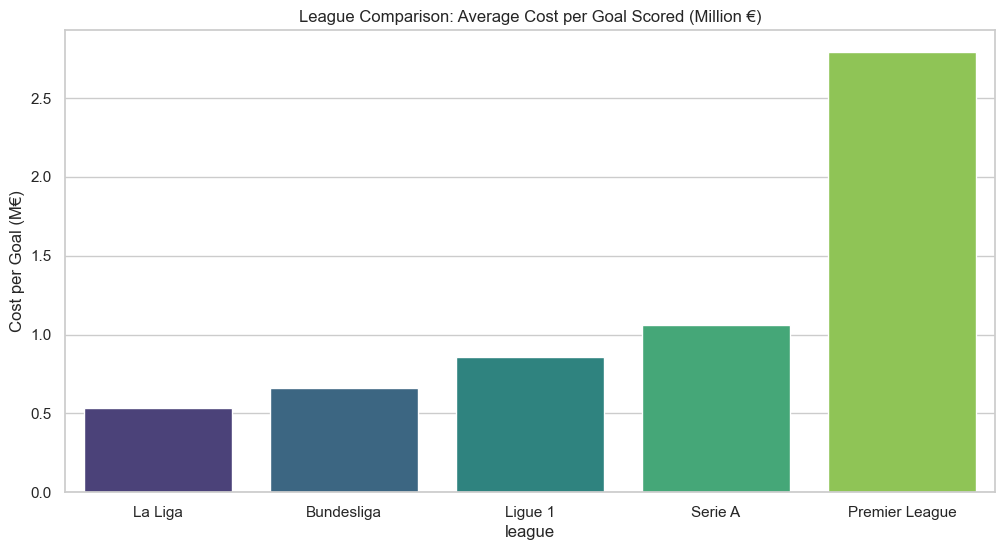

In [50]:
plt.figure(figsize=(12, 6))
avg_cost = df.groupby('league')['cost_per_goal_m_euro'].mean().sort_values()
sns.barplot(x=avg_cost.index, y=avg_cost.values, hue=avg_cost.index, palette="viridis", legend=False)

plt.title('League Comparison: Average Cost per Goal Scored (Million €)')
plt.ylabel('Cost per Goal (M€)')
plt.show()

### Interpretation
- Average cost-per-goal differs across leagues; however, league structures, player markets, and tactical styles confound direct comparisons.
- Treat this as a descriptive benchmark, not proof of (in)efficiency.

Segue: We quantify global relationships via a correlation heatmap to narrow candidate drivers of success.

## Correlation Heatmap
To fulfill the statistical validation requirement, we generate a heatmap to identify which features (Money, Stadium, or Goals) have the strongest mathematical link to finishing in the Top 5.

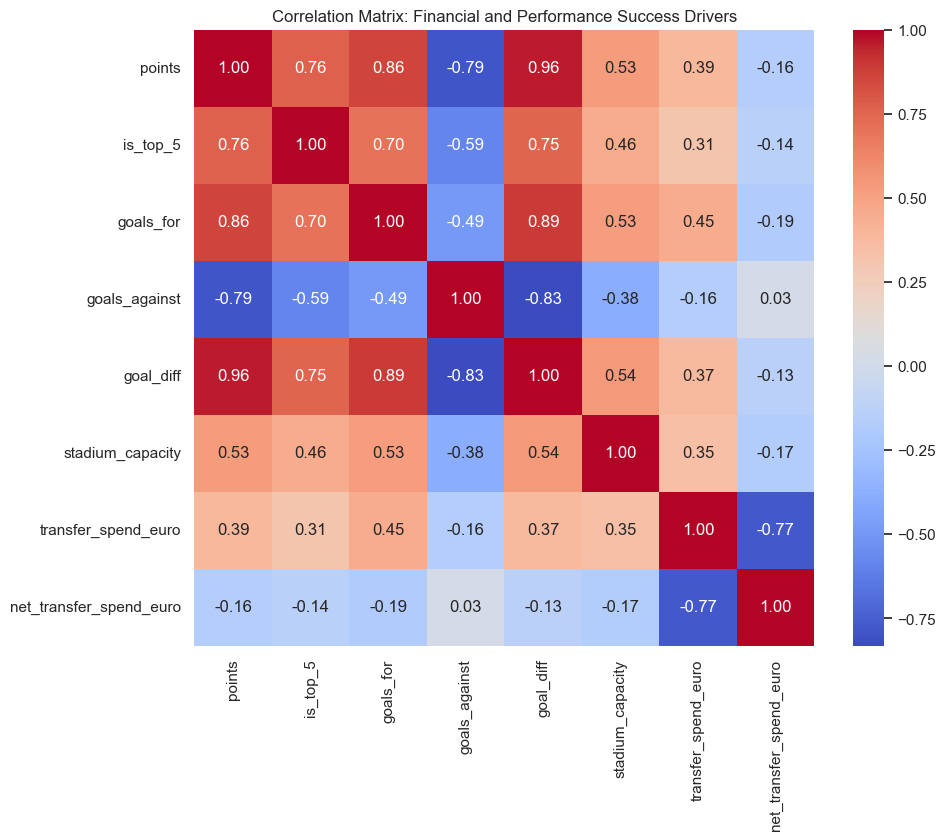

In [51]:
# Selection of features for the correlation matrix
corr_cols = ['points', 'is_top_5', 'goals_for', 'goals_against', 'goal_diff', 
             'stadium_capacity', 'transfer_spend_euro', 'net_transfer_spend_euro']

plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Financial and Performance Success Drivers')
plt.show()

### Interpretation
- As expected, `points` aligns strongly with `goal_diff` and with both attacking and defensive components.
- Money variables show weaker and noisier associations; spend matters, but not deterministically.

Next: We use these EDA insights to inform modeling choices (features and evaluation) in the advanced analysis notebook.

### coordinates on the Map

In [53]:
import plotly.express as px

# Load all coordinate files
coord_files = {
    'Bundesliga': '../data/coordinates_bl_22_24.csv',
    'Ligue 1': '../data/coordinates_l1_22_24.csv',
    'La Liga': '../data/coordinates_ll_22_24.csv',
    'Premier League': '../data/coordinates_pl_22_24.csv',
    'Serie A': '../data/coordinates_sa_22_24.csv'
}

# Function to parse coordinates (e.g., "48.6685° N" -> 48.6685)
def parse_coord(coord_str):
    coord_str = str(coord_str).strip()
    value = float(coord_str.replace('°', '').replace('N', '').replace('S', '').replace('E', '').replace('W', '').strip())
    if 'S' in coord_str or 'W' in coord_str:
        value = -value
    return value

# Load and combine all coordinates
all_coords = []
for league, filepath in coord_files.items():
    try:
        coords_df = pd.read_csv(filepath)
        coords_df['League'] = league
        coords_df['Lat'] = coords_df['Latitude'].apply(parse_coord)
        coords_df['Lon'] = coords_df['Longitude'].apply(parse_coord)
        all_coords.append(coords_df)
    except FileNotFoundError:
        print(f"File not found: {filepath}")

coords_all = pd.concat(all_coords, ignore_index=True)

# Get Top 5 teams from the main dataframe
top5_teams = df[df['is_top_5'] == 1][['team', 'league']].drop_duplicates()

# Merge to filter only Top 5 teams
coords_top5 = coords_all.merge(top5_teams, left_on=['Team', 'League'], right_on=['team', 'league'], how='inner')

# Create interactive map with Plotly - only Top 5 teams
fig = px.scatter_mapbox(
    coords_top5,
    lat='Lat',
    lon='Lon',
    color='League',
    hover_name='Team',
    hover_data={'Stadium': True, 'Lat': False, 'Lon': False},
    zoom=4,
    center={'lat': 48, 'lon': 5},
    height=600,
    title='Top 5 Teams per League - Stadium Locations (2022-2024)'
)

fig.update_layout(
    mapbox_style='open-street-map',
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0}
)

fig.show()
print(f"Showing {len(coords_top5)} Top 5 teams across all leagues")

Showing 38 Top 5 teams across all leagues


### Interpretation: Geographic Distribution of Top 5 Teams

The map displays the locations of the most successful clubs (Top 5) across the five major European leagues. Several interesting patterns emerge:

#### 1. **Regional Concentration of Success**
- **Premier League (England)**: Top teams are heavily concentrated in **Greater London** (Chelsea, Arsenal, Tottenham) and the **Northwest** (Manchester City, Manchester United, Liverpool). Rural areas and smaller cities are rarely represented.
- **Bundesliga (Germany)**: **Bayern Munich** dominates in the south, while Dortmund and Leipzig represent the north/east. Geographic distribution is broader than in England.
- **La Liga (Spain)**: Clear bipolarity between **Madrid** (Real, Atlético) and **Barcelona**. Remaining success is distributed across Valencia, Sevilla, and the Basque Country.
- **Serie A (Italy)**: Strong concentration in the **North** (Milan, Turin, Bergamo). Southern Italy is nearly absent among top teams.
- **Ligue 1 (France)**: **Paris** dominates overwhelmingly. Only occasionally do provincial clubs like Lyon, Marseille, or Monaco break into the Top 5.

#### 2. **Implications for Our Project**

| Observation | Relevance to Analysis |
|-------------|----------------------|
| **Metropolis Dominance** | Larger cities = higher stadium capacity = more revenue = higher transfer budgets. This confirms our correlation between `stadium_capacity` and `points` (~0.54). |
| **Economic Hotspots** | Top teams are located in economically strong regions. This explains the high `transfer_spend_euro` values among successful clubs. |
| **Infrastructure Advantage** | Metropolitan areas offer better training facilities, youth academies, and sponsor networks-factors not directly captured in our data but influencing success. |
| **Fan Base as Success Factor** | Metropolises have larger potential fan bases, leading to higher ticket revenues and merchandising-an indirect driver of `transfer_spend_euro`. |

#### 3. **Limitations**
- Coordinates alone do not explain any causal relationship with sporting success.
- Promoted teams from smaller cities (e.g., Brentford, Lens, Union Berlin) demonstrate that **efficiency** (`cost_per_goal_m_euro`) can partially compensate for geographic disadvantages.
- Regional economic strength correlates with success but is not a guarantee-as our correlation analysis shows (weak correlation between spending and points).

**Conclusion**: The geographic distribution of Top 5 teams reflects economic inequality within leagues and supports our EDA findings: infrastructure and financial resources are necessary but not sufficient conditions for success.

# Interpretation of Results

## Key Findings

### 1. **Market Efficiency: The Premier League Premium**
The 'Average Cost per Goal' metric reveals a stark contrast across European leagues:
- **La Liga** leads efficiency at **€0.53M per goal** - the most cost-effective league
- **Bundesliga** follows at **€0.68M per goal**
- **Ligue 1** at **€0.87M per goal**
- **Serie A** at **€1.05M per goal**
- **Premier League** trails significantly at **€2.73M per goal** - **over 5x more expensive** than La Liga

**Interpretation**: The Premier League spends €149.96M on average yet produces only 57.42 goals per season, while La Liga spends just €29.35M for comparable output (49.25 goals). This indicates significant market inefficiency in English football; premium player valuations driven by higher television revenues and global brand appeal rather than pure sporting returns. Spanish and German clubs demonstrate superior recruitment ROI.

### 2. **Performance Paradox: Points Don't Follow Spending**
Despite the financial hierarchy, league point accumulation tells a different story:

| League | Avg Spending (€M) | Avg Points | Cost Per Point |
|---|---|---|---|
| **La Liga** | 29.35 | 52.12 | **€562K** |
| **Premier League** | 149.96 | 52.43 | **€2.86M** |
| **Serie A** | 55.71 | 51.50 | **€1.08M** |

**Key Insight**: La Liga achieves nearly identical points (52.12) as the Premier League (52.43) at 1/5th the cost. This demonstrates that **strategic efficiency and tactical coherence outweigh absolute spending power** in determining league-wide competitive balance.

### 3. **Correlation Analysis: What Actually Drives Success?**

| Variable Pair | Correlation | Strength | Interpretation |
|---|---|---|---|
| **Points ↔ Goal Difference** | **+0.96** | Extremely Strong | Goal difference is the fundamental driver of league position |
| **Points ↔ Goals For** | **+0.86** | Strong | Offensive firepower essential for league success |
| **Is_Top_5 ↔ Goals For** | **+0.70** | Strong | Elite status (Top 5) heavily dependent on attacking prowess |
| **Points ↔ Transfer Spend** | **+0.39** | Weak | Money has marginal impact on actual point accumulation |
| **Points ↔ Net Transfer Spend** | **-0.16** | Weak Negative | Higher net spending slightly correlates with worse performance |
| **Goals Against ↔ Points** | **-0.79** | Strong Negative | Defensive solidity is nearly as important as attack |

**Critical Insight**: The negative correlation between net transfer spending and points (-0.16) suggests that **aggressive recruitment spending is counterproductive**. Clubs attempting rapid rebuilds through major transfer outlays often underperform, indicating integration challenges and strategic misalignment override raw expenditure.

### 4. **Defensive Excellence is Underestimated**
- Defensive metrics show strong inverse correlations with success: goals against correlates -0.79 with points
- Goal difference (attack - defense) remains the single best predictor at 0.96 correlation with points
- **Teams cannot buy their way to Top 5 status through offense alone**-defensive organization and efficiency are equally critical

### 5. **Stadium Capacity: Infrastructure ≠ Success, but Positive Link to Points**
- Scatterplot shows an upward slope: larger stadiums tend to host teams with higher point totals; heatmap corroborates with a moderate positive stadium_capacity ↔ points correlation (~0.54).
- Premier League clubs cluster at high capacities yet show wider point dispersion, hinting at diminishing returns from sheer size.
- Serie A/La Liga points are more tightly distributed for given capacities, implying efficient conversion of fanbase scale into results.

### 6. **Jointplot: Premier League Distribution Stands Out**
- In the net_transfer_spend vs goal_diff jointplot, the Premier League exhibits the widest spread and a heavy right tail in spending; other leagues cluster closer to the origin.
- This indicates higher variance in ROI within the Premier League-some heavy spenders still post modest goal differences, while others overperform their spend; continental leagues show more compact, efficient profiles.

### 7. **Numeric Financial EDA (Spending, Income, Net) with Spread**
- New dispersion table (min/mean/max/std) shows **Premier League** has both the highest max net spend and the largest standard deviation, confirming volatile spending behavior; **La Liga/Bundesliga** show tighter ranges and lower std, indicating disciplined markets.
- Income extremes reveal continental leagues offset spend via sales (higher max incomes), cushioning net outlay and stabilizing variance.
- Cost per point/goal spread highlights risk: PL clubs face the widest range of efficiency outcomes; La Liga's lower std suggests more predictable ROI.

## Actionable Conclusions

### 1. **The Premier League Efficiency Crisis**
At €2.86M per point, Premier League clubs pay a "branding premium" that yields no competitive advantage. For forward-thinking clubs, this market inefficiency presents opportunity: **Spanish and German models offer superior ROI**.

### 2. **Less is More in Recruitment**
The negative correlation between net spending and points suggests:
- **Slow, strategic recruitment outperforms rapid overhauls**
- Player integration and tactical coherence matter more than squad depth
- Clubs aiming for Top 5 should focus on targeted, strategic signings rather than volume spending

### 3. **The Balanced Approach Wins**
- Goal difference (0.96 correlation with points) requires **both** strong attack AND solid defense
- Over-investing in one dimension while neglecting the other is inefficient
- Top 5 clubs succeed through organizational excellence, not financial dominance

### 4. **League Competitiveness Trends**
- La Liga and Bundesliga operate more efficient markets-expect continued competitive strength
- Premier League's spending advantage is unsustainable without performance gains
- Ligue 1 and Serie A occupy middle ground but show potential for value-based recruitment success

# Synthesis and Next Steps

## What the EDA suggests

- Success maps most cleanly to on-pitch fundamentals: goal difference, goals for, and controlling goals against.
- Financial variables (transfer spend, net spend) relate to performance but with high variance and league-specific noise. Spend is a necessary enabler for many clubs, not a guarantee.
- Stadium capacity correlates with points and may proxy long-run resources and fanbase scale-but it is not causal within a single season (endogeneity: success ↔ capacity).
- Efficiency metrics (e.g., cost-per-goal) differ by league and reflect market structure and recruitment styles; treat them as descriptive, not prescriptive.

## Guardrails for interpretation

- Correlations are sample- and period-dependent; do not equate them with causation.
- Outliers (one-season overhauls, injury shocks, managerial changes) can dominate patterns for specific clubs.

## Modeling implications (hand-off to Notebook 02)

- Features: emphasize structural capacity (stadium), resource flow (spend, net spend), and a normalized efficiency signal (cost-per-goal).
- Targets: predict `is_top_5` as a classification task, mindful of class imbalance.
- Validation: compare linear and non-linear models; inspect confusion matrix and feature importance.

Next, we operationalize these hypotheses in the advanced analytics notebook and evaluate how well these features predict Top 5 status.